# Four-target SFP: training coverage and validation failures

本实验检验：失败验证布局在训练集中是否拥有更少的相似布局。
只加载已有模型、训练布局及验证布局；不训练，不加载测试集。

**固定设置**：10,000 epochs、seed 4 的 `best.pt`；全部验证布局；
访问容差 **0.02**；1,000 步 RK4，从精确起点出发，与原实验一致。
四目标均被访问即成功，不要求与专家访问顺序一致，也不据此判断路径最优性。

**相似布局**：以验证布局四目标为圆心，半径均为 r。
训练布局四目标必须与四个圆形成一一匹配，每个训练布局最多计数一次。
圆重叠时也不能重复使用同一目标。编号不影响匹配，不做旋转、镜像或平移对齐。
两个数据集必须具有同一固定起点，否则本 notebook 会停止。

预设 r = 0.02, 0.05, 0.10, 0.15, 0.20；全部报告，0.10 仅作为案例图和分组图的默认展示半径。
这些半径单位与数据坐标相同，与访问容差是两回事。

将 notebook 放在 streaming-flow-policy 仓库内，选择原实验的 Python 环境，按顺序运行。
如自动定位失败，在第一个代码单元格填入 `PROJECT_ROOT_OVERRIDE`。
输出保存到 `experiments/four_boxes_experiments/four_targets/analysis/coverage_budget_10000_seed_4_visit_002/`。
已保存的轨迹和计数可在重新运行时复用；缓存按数据、模型及分析设置校验。

这是验证集上的探索性关联分析；该模型曾根据验证表现挑选，结果不代表独立测试结论。
当前提供的是未运行真实数据的分析 notebook。


In [33]:
from pathlib import Path
import itertools
import hashlib
import json
import os
import subprocess
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import torch
from torch import nn
from IPython.display import display

PROJECT_ROOT_OVERRIDE = None  # Example: Path('/home/matcho/projects/streaming-flow-policy')
CHECKPOINT_OVERRIDE = None    # Optional explicit path to the SAME model's best.pt
VISIT_TOLERANCE = 0.02
RADII = np.array([0.02, 0.05, 0.10, 0.15, 0.20], dtype=np.float64)
DISPLAY_RADIUS = 0.10
EVAL_STEPS = 1000
ROLLOUT_BATCH_SIZE = 100
TRAIN_BLOCK_SIZE = 2000
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ANALYSIS_VERSION = 'four_circle_coverage_v1'

def find_project_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        return Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]
    try:
        result = subprocess.run(['git', '-C', str(here), 'rev-parse', '--show-toplevel'],
                                check=True, capture_output=True, text=True)
        candidates.insert(0, Path(result.stdout.strip()))
    except (subprocess.CalledProcessError, FileNotFoundError):
        pass
    for root in candidates:
        if (root / 'experiments/four_boxes_experiments/four_targets/datasets/v1').is_dir():
            return root
    raise FileNotFoundError('Run inside the repository, or set PROJECT_ROOT_OVERRIDE.')

PROJECT_ROOT = find_project_root()
TASK_ROOT = PROJECT_ROOT / 'experiments/four_boxes_experiments/four_targets'
DATASET_DIR = TASK_ROOT / 'datasets/v1'
RUN_DIR = TASK_ROOT / 'runs/conditional_mlp_canonical_seed_sweep/budget_10000_seed_4'
CHECKPOINT_PATH = Path(CHECKPOINT_OVERRIDE).expanduser().resolve() if CHECKPOINT_OVERRIDE else RUN_DIR / 'best.pt'
OUTPUT_DIR = TASK_ROOT / 'analysis/coverage_budget_10000_seed_4_visit_002'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert np.all(RADII > 0) and np.all(np.diff(RADII) > 0)
assert np.any(np.isclose(RADII, DISPLAY_RADIUS))
print('Project:', PROJECT_ROOT)
print('Device:', DEVICE)
print('Checkpoint:', CHECKPOINT_PATH)
print('Output:', OUTPUT_DIR)


Project: /home/matcho/projects/streaming-flow-policy
Device: cuda
Checkpoint: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/conditional_mlp_canonical_seed_sweep/budget_10000_seed_4/best.pt
Output: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/analysis/coverage_budget_10000_seed_4_visit_002


## 1. Load fixed datasets and the selected checkpoint


In [34]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def atomic_npz(path, **arrays):
    path = Path(path)
    tmp = path.with_name(path.name + '.tmp')
    with tmp.open('wb') as f:
        np.savez_compressed(f, **arrays)
    os.replace(tmp, path)

def load_split(name):
    with np.load(DATASET_DIR / f'{name}.npz', allow_pickle=False) as f:
        split = {key: f[key].copy() for key in f.files}
    n = len(split['targets'])
    for key, shape in {'starts': (n, 2), 'targets': (n, 4, 2), 'conditions': (n, 10)}.items():
        if split[key].shape != shape or not np.isfinite(split[key]).all():
            raise ValueError(f'Invalid {name}/{key}')
    np.testing.assert_allclose(split['conditions'], np.concatenate(
        [split['starts'], split['targets'].reshape(n, 8)], axis=1), rtol=0, atol=1e-7)
    return split

train_split = load_split('train')
validation_split = load_split('validation')
TRAIN_TARGETS = train_split['targets'].astype(np.float64)
VALIDATION_TARGETS = validation_split['targets'].astype(np.float64)
N_TRAIN, N_VALIDATION = len(TRAIN_TARGETS), len(VALIDATION_TARGETS)
if not N_TRAIN or not N_VALIDATION:
    raise ValueError('Both splits must be nonempty.')
fixed_start = train_split['starts'][0]
for split in [train_split, validation_split]:
    np.testing.assert_allclose(split['starts'], np.broadcast_to(fixed_start, split['starts'].shape),
                               rtol=0, atol=1e-7, err_msg='This analysis requires a shared fixed start.')

def canonicalize_box_inputs(inputs):
    boxes = inputs[:, 5:].reshape(-1, 4, 2)
    for coordinate in [1, 0]:
        order = torch.argsort(boxes[:, :, coordinate], dim=1, stable=True)
        boxes = torch.gather(boxes, 1, order.unsqueeze(-1).expand(-1, -1, 2))
    return torch.cat([inputs[:, :5], boxes.reshape(-1, 8)], dim=1)

class CanonicalConditionalVelocityMLP(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        width = 13
        for _ in range(4):
            layers.extend([nn.Linear(width, 128), nn.SiLU()])
            width = 128
        layers.append(nn.Linear(width, 2))
        self.network = nn.Sequential(*layers)
    def forward(self, inputs):
        return self.network(2.0 * canonicalize_box_inputs(inputs) - 1.0)

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=True)
saved_config = checkpoint.get('config', {})
for key, expected in {'num_epochs': 10000, 'training_seed': 4}.items():
    if key in saved_config and saved_config[key] != expected:
        raise ValueError(f'Unexpected checkpoint {key}: {saved_config[key]}')
dataset_hashes = {f'{name}.npz': sha256_file(DATASET_DIR / f'{name}.npz')
                  for name in ['train', 'validation']}
for name, digest in saved_config.get('dataset_sha256', {}).items():
    if name in dataset_hashes and digest != dataset_hashes[name]:
        raise ValueError(f'The checkpoint used a different dataset: {name}')
model = CanonicalConditionalVelocityMLP().to(device=DEVICE, dtype=torch.float64)
model.load_state_dict(checkpoint['model'], strict=True)
model.eval()
manifest = {
    'analysis_version': ANALYSIS_VERSION,
    'dataset_sha256': dataset_hashes,
    'checkpoint_sha256': sha256_file(CHECKPOINT_PATH),
    'checkpoint_relative_path': os.path.relpath(CHECKPOINT_PATH, PROJECT_ROOT),
    'training_budget': 10000, 'training_seed': 4,
    'selected_epoch': int(checkpoint['epoch']),
    'visit_tolerance': VISIT_TOLERANCE, 'radii': RADII.tolist(),
    'display_radius': DISPLAY_RADIUS, 'eval_steps': EVAL_STEPS,
    'num_training_layouts': N_TRAIN, 'num_validation_layouts': N_VALIDATION,
    'start_mode': 'exact_fixed_start', 'matching': 'minimum_maximum_distance_over_24_permutations',
    'evaluation_dtype': 'float64', 'device': str(DEVICE), 'torch_version': str(torch.__version__),
}
CACHE_KEY = hashlib.sha256(json.dumps(manifest, sort_keys=True).encode()).hexdigest()
manifest_path = OUTPUT_DIR / 'manifest.json'
if manifest_path.exists():
    old = json.loads(manifest_path.read_text(encoding='utf-8'))
    if old != manifest:
        raise ValueError('Analysis settings/data changed. Choose a NEW OUTPUT_DIR to preserve prior results.')
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(f'Training layouts: {N_TRAIN}; validation layouts: {N_VALIDATION}')
print(f'Selected checkpoint epoch: {checkpoint["epoch"]}; visit tolerance: {VISIT_TOLERANCE}')
print('Only train and validation splits have been loaded.')


Training layouts: 10000; validation layouts: 1000
Selected checkpoint epoch: 7834; visit tolerance: 0.02
Only train and validation splits have been loaded.


## 2. Generate validation trajectories (cached by batch)
中断后重新运行本单元格会继续未完成的批次。CPU 或消费级 GPU 的 float64 推理可能较慢。


In [35]:
@torch.no_grad()
def generate_paths(model, split, num_steps=1000):
    parameter = next(model.parameters())
    conditions = torch.as_tensor(split['conditions'], dtype=parameter.dtype, device=parameter.device)
    actions = torch.as_tensor(split['starts'], dtype=parameter.dtype, device=parameter.device).clone()
    model.eval()
    # Transfer to CPU once per batch, rather than once per RK4 step.
    paths = torch.empty((len(actions), num_steps + 1, 2), dtype=actions.dtype, device=actions.device)
    paths[:, 0] = actions
    dt = 1.0 / num_steps
    def velocity(a, tau):
        t = torch.full((len(a), 1), tau, dtype=a.dtype, device=a.device)
        return model(torch.cat([a, t, conditions], dim=1))
    for step in range(num_steps):
        tau = step * dt
        k1 = velocity(actions, tau)
        k2 = velocity(actions + dt * k1 / 2, tau + dt / 2)
        k3 = velocity(actions + dt * k2 / 2, tau + dt / 2)
        k4 = velocity(actions + dt * k3, min(tau + dt, 1.0))
        actions = actions + dt / 6 * (k1 + 2*k2 + 2*k3 + k4)
        paths[:, step + 1] = actions
    result = paths.cpu().numpy()
    if not np.isfinite(result).all():
        raise RuntimeError('Non-finite rollout; no cache was saved for this batch.')
    return result

rollout_dir = OUTPUT_DIR / 'rollout_batches'
rollout_dir.mkdir(exist_ok=True)
all_paths = np.empty((N_VALIDATION, EVAL_STEPS + 1, 2), dtype=np.float64)
started = time.perf_counter()
for lo in range(0, N_VALIDATION, ROLLOUT_BATCH_SIZE):
    hi = min(lo + ROLLOUT_BATCH_SIZE, N_VALIDATION)
    cache_path = rollout_dir / f'{lo:05d}_{hi:05d}.npz'
    if cache_path.exists():
        with np.load(cache_path, allow_pickle=False) as f:
            if f['cache_key'].item() != CACHE_KEY:
                raise ValueError('Rollout cache mismatch; choose a new output directory.')
            paths = f['paths'].copy()
        status = 'cached'
    else:
        subset = {k: validation_split[k][lo:hi] for k in ['starts', 'conditions']}
        paths = generate_paths(model, subset, EVAL_STEPS)
        atomic_npz(cache_path, cache_key=np.array(CACHE_KEY), paths=paths)
        status = 'computed'
    if paths.shape != (hi - lo, EVAL_STEPS + 1, 2) or not np.isfinite(paths).all():
        raise ValueError('Invalid rollout cache.')
    all_paths[lo:hi] = paths
    print(f'Validation {hi}/{N_VALIDATION}: {status}; elapsed {time.perf_counter()-started:.1f}s', flush=True)


Validation 100/1000: cached; elapsed 0.0s
Validation 200/1000: cached; elapsed 0.0s
Validation 300/1000: cached; elapsed 0.0s
Validation 400/1000: cached; elapsed 0.0s
Validation 500/1000: cached; elapsed 0.0s
Validation 600/1000: cached; elapsed 0.0s
Validation 700/1000: cached; elapsed 0.0s
Validation 800/1000: cached; elapsed 0.1s
Validation 900/1000: cached; elapsed 0.1s
Validation 1000/1000: cached; elapsed 0.1s


## 3. Determine success from target-to-polyline distances
对 RK4 采样点之间的线段计算距离，不只看离散采样点；不检查专家访问顺序。


In [36]:
def target_distances(path, targets):
    p0 = path[:-1]
    vectors = np.diff(path, axis=0)
    offsets = targets[:, None, :] - p0[None, :, :]
    denominator = np.maximum(np.sum(vectors**2, axis=1), 1e-30)
    fraction = np.clip(np.sum(offsets * vectors[None, :, :], axis=-1) / denominator[None, :], 0, 1)
    nearest = p0[None, :, :] + fraction[:, :, None] * vectors[None, :, :]
    return np.linalg.norm(targets[:, None, :] - nearest, axis=-1).min(axis=1)

distances = np.stack([target_distances(path, targets)
                      for path, targets in zip(all_paths, VALIDATION_TARGETS)])
visit_counts = (distances <= VISIT_TOLERANCE).sum(axis=1)
success = visit_counts == 4
worst_distance = distances.max(axis=1)
print(f'All validation layouts: {success.sum()}/{N_VALIDATION} = {success.mean():.2%}')
print('Visit histogram [0, 1, 2, 3, 4]:', np.bincount(visit_counts, minlength=5).tolist())

# Reproduce the original diagnostic subset without restricting the main analysis to it.
if N_VALIDATION >= 100:
    original_indices = np.arange(100)
    print(f'Original subset (validation indices 0–99): {success[original_indices].mean():.1%}')
    print('The research log reports 71% at tolerance 0.02; check data/checkpoint/settings if different.')


All validation layouts: 650/1000 = 65.00%
Visit histogram [0, 1, 2, 3, 4]: [8, 37, 110, 195, 650]
Original subset (validation indices 0–99): 71.0%
The research log reports 71% at tolerance 0.02; check data/checkpoint/settings if different.


## 4. Count training layouts with an exact one-to-one match

For validation targets V and training targets T, define

\[
d_\mathrm{match}(V,T)=\min_{\pi\in S_4}\max_{j=1,\ldots,4}\|V_j-T_{\pi(j)}\|_2.
\]

A training layout counts at radius r exactly when this distance is at most r.
All 24 assignments are examined. A nearest-target test alone is insufficient because it can reuse a target.
Counts refer to training **layouts**, not generated noisy training samples.


In [37]:
PERMUTATIONS = np.array(list(itertools.permutations(range(4))), dtype=np.int64)

def matching_distances(query, training_targets, block_size=2000):
    """Minimum bottleneck distance for each complete training layout, independent of labels."""
    query = np.asarray(query, dtype=np.float64)
    training_targets = np.asarray(training_targets, dtype=np.float64)
    result = np.empty(len(training_targets), dtype=np.float64)
    for lo in range(0, len(training_targets), block_size):
        block = training_targets[lo:lo + block_size]
        d2 = np.sum((query[None, :, None, :] - block[:, None, :, :]) ** 2, axis=-1)
        best2 = np.full(len(block), np.inf)
        for permutation in PERMUTATIONS:
            candidate2 = d2[:, np.arange(4), permutation].max(axis=1)
            np.minimum(best2, candidate2, out=best2)
        result[lo:lo + len(block)] = np.sqrt(best2)
    return result

# Small, meaningful checks of the matching definition.
q = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
assert matching_distances(q, q[[2, 0, 3, 1]][None])[0] == 0
bad = np.array([[0., 0.], [0., 0.01], [1., 0.], [1., 1.]])
assert matching_distances(q, bad[None])[0] > 0.1
# Every point has a nearby counterpart, but two query circles share only ONE candidate:
# a mere row/column nearest-distance test would incorrectly accept this layout.
overlap_q = np.array([[0., 0.], [0.08, 0.], [0.5, 0.], [0.9, 0.]])
overlap_t = np.array([[0.04, 0.], [0.5, 0.], [0.52, 0.], [0.9, 0.]])
pairwise = np.linalg.norm(overlap_q[:, None] - overlap_t[None], axis=-1)
assert (pairwise.min(axis=0) <= 0.05).all() and (pairwise.min(axis=1) <= 0.05).all()
assert matching_distances(overlap_q, overlap_t[None])[0] > 0.05
print('Permutation and overlapping-circle matching checks passed.')

coverage_path = OUTPUT_DIR / 'coverage_cache.npz'
if coverage_path.exists():
    with np.load(coverage_path, allow_pickle=False) as f:
        if f['cache_key'].item() != CACHE_KEY:
            raise ValueError('Coverage cache mismatch.')
        coverage_counts = f['counts'].copy()
        nearest_distance = f['nearest_distance'].copy()
        nearest_training_index = f['nearest_training_index'].copy()
        coverage_done = f['done'].copy()
else:
    coverage_counts = np.zeros((N_VALIDATION, len(RADII)), dtype=np.int64)
    nearest_distance = np.full(N_VALIDATION, np.nan)
    nearest_training_index = np.full(N_VALIDATION, -1, dtype=np.int64)
    coverage_done = np.zeros(N_VALIDATION, dtype=bool)

started = time.perf_counter()
pending = np.flatnonzero(~coverage_done)
for step, i in enumerate(pending, 1):
    d = matching_distances(VALIDATION_TARGETS[i], TRAIN_TARGETS, TRAIN_BLOCK_SIZE)
    coverage_counts[i] = (d[:, None] <= RADII[None, :]).sum(axis=0)
    nearest_training_index[i] = np.argmin(d)
    nearest_distance[i] = d[nearest_training_index[i]]
    coverage_done[i] = True
    if step % 25 == 0 or step == len(pending):
        atomic_npz(coverage_path, cache_key=np.array(CACHE_KEY), counts=coverage_counts,
                   nearest_distance=nearest_distance, nearest_training_index=nearest_training_index,
                   done=coverage_done)
        print(f'Coverage {coverage_done.sum()}/{N_VALIDATION}; elapsed {time.perf_counter()-started:.1f}s', flush=True)
assert coverage_done.all()
assert np.all(np.diff(coverage_counts, axis=1) >= 0)
print('Coverage complete. Each training layout is counted at most once per radius.')


Permutation and overlapping-circle matching checks passed.
Coverage complete. Each training layout is counted at most once per radius.


In [32]:
# 提高访问容差，使用已有轨迹的目标距离重新分类
VISIT_TOLERANCE = 0.05

visit_counts = (distances <= VISIT_TOLERANCE).sum(axis=1)
success = visit_counts == 4
worst_distance = distances.max(axis=1)

# 新结果单独保存，保留之前 0.02 的分析
OUTPUT_DIR = (
    TASK_ROOT
    / "analysis"
    / "coverage_budget_10000_seed_4_visit_005"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 保存这次报告对应的设置
report_manifest = dict(manifest)
report_manifest["visit_tolerance"] = VISIT_TOLERANCE
report_manifest["reused_existing_paths_and_coverage"] = True

(OUTPUT_DIR / "manifest.json").write_text(
    json.dumps(report_manifest, indent=2),
    encoding="utf-8",
)

print(f"访问容差：{VISIT_TOLERANCE}")
print(f"成功：{success.sum()}/{len(success)}")
print(f"失败：{(~success).sum()}/{len(success)}")
print(f"成功率：{success.mean():.2%}")
print("结果保存到：", OUTPUT_DIR)

访问容差：0.05
成功：833/1000
失败：167/1000
成功率：83.30%
结果保存到： /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/analysis/coverage_budget_10000_seed_4_visit_005


## 5. Save one row per validation layout and compare groups
均值、分位数与零计数比例一起报告；计数通常偏斜，不能只比较均值。失败组计数更低是支持性关联证据，不是因果证明。


In [38]:
def count_column(radius):
    return f'count_r_{radius:.3f}'.replace('.', 'p')

results = pd.DataFrame({
    'validation_index': np.arange(N_VALIDATION),
    'success': success,
    'visited_count': visit_counts,
    'worst_target_distance': worst_distance,
    'nearest_training_index': nearest_training_index,
    'nearest_matching_distance': nearest_distance,
})
for j in range(4):
    results[f'target_{j}_distance'] = distances[:, j]
for j, radius in enumerate(RADII):
    results[count_column(radius)] = coverage_counts[:, j]
results.to_csv(OUTPUT_DIR / 'per_validation_layout.csv', index=False)

rows = []
for j, radius in enumerate(RADII):
    for label, mask in [('Success', success), ('Failure', ~success)]:
        x = coverage_counts[mask, j]
        rows.append({'radius': radius, 'group': label, 'n_layouts': len(x),
                     'mean_count': x.mean() if len(x) else np.nan,
                     'median_count': np.median(x) if len(x) else np.nan,
                     'q25_count': np.quantile(x, .25) if len(x) else np.nan,
                     'q75_count': np.quantile(x, .75) if len(x) else np.nan,
                     'zero_count_fraction': np.mean(x == 0) if len(x) else np.nan})
summary = pd.DataFrame(rows)
summary.to_csv(OUTPUT_DIR / 'coverage_group_summary.csv', index=False)
display(summary.round(4))

# Descriptive rank association; no independence or causal claim is inferred.
rank_rows = []
for j, radius in enumerate(RADII):
    count_rank = pd.Series(coverage_counts[:, j]).rank(method='average')
    error_rank = pd.Series(worst_distance).rank(method='average')
    rho = count_rank.corr(error_rank) if count_rank.nunique() > 1 and error_rank.nunique() > 1 else np.nan
    rank_rows.append({'radius': radius, 'spearman_count_vs_worst_distance': rho})
associations = pd.DataFrame(rank_rows)
associations.to_csv(OUTPUT_DIR / 'descriptive_associations.csv', index=False)
display(associations.round(4))
print('Negative rank correlation means higher coverage tends to accompany smaller errors.')
print('NaN means the association could not be calculated, e.g. all counts are equal.')


,radius,group,n_layouts,mean_count,median_count,q25_count,q75_count,zero_count_fraction
0,0.02,Success,650,0.0000,0.0,0.0,0.00,1.0000
1,0.02,Failure,350,0.0000,0.0,0.0,0.00,1.0000
2,0.05,Success,650,0.0108,0.0,0.0,0.00,0.9892
3,0.05,Failure,350,0.0114,0.0,0.0,0.00,0.9886
4,0.10,Success,650,1.8754,2.0,1.0,3.00,0.2015
5,0.10,Failure,350,1.6571,1.0,0.0,3.00,0.2657
6,0.15,Success,650,32.9369,32.0,21.0,42.00,0.0000
7,0.15,Failure,350,28.5314,26.5,16.0,38.00,0.0000
8,0.20,Success,650,217.3723,204.5,143.0,276.00,0.0000
9,0.20,Failure,350,191.4429,180.5,114.0,256.75,0.0000


,radius,spearman_count_vs_worst_distance
0,0.02,NaN
1,0.05,-0.0113
2,0.10,-0.0805
3,0.15,-0.1750
4,0.20,-0.1632


Negative rank correlation means higher coverage tends to accompany smaller errors.
NaN means the association could not be calculated, e.g. all counts are equal.


## 6. Visualize distributions and success versus coverage
左图显示完整计数分布，右图显示固定计数区间内的成功率。空区间跳过；小样本区间的比例不稳定。


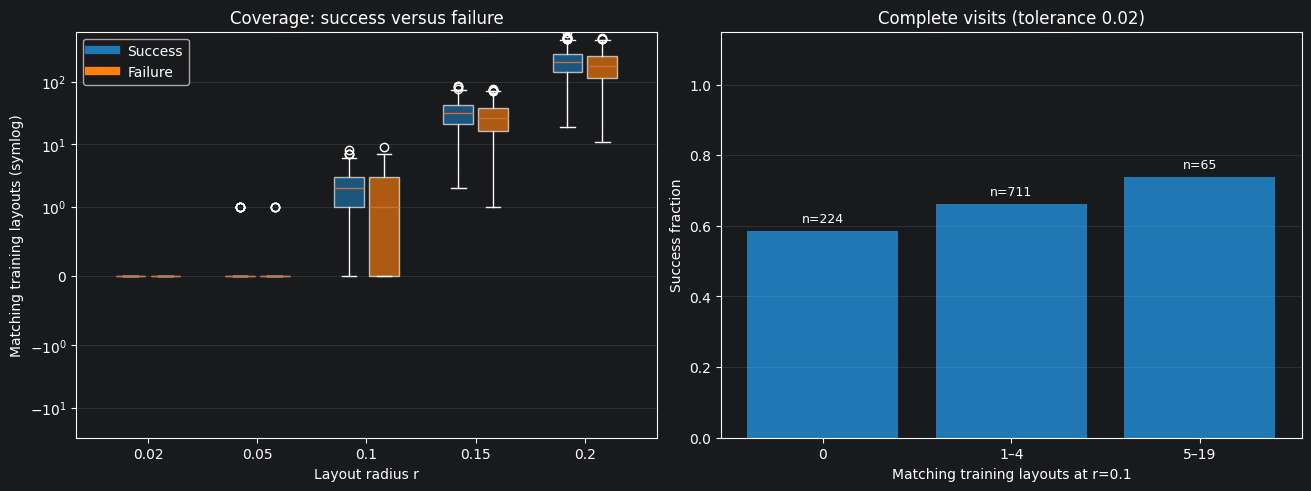

,count_bin,n_layouts,n_success,success_rate
0,0,224,131,0.584821
1,1–4,711,471,0.662447
2,5–19,65,48,0.738462


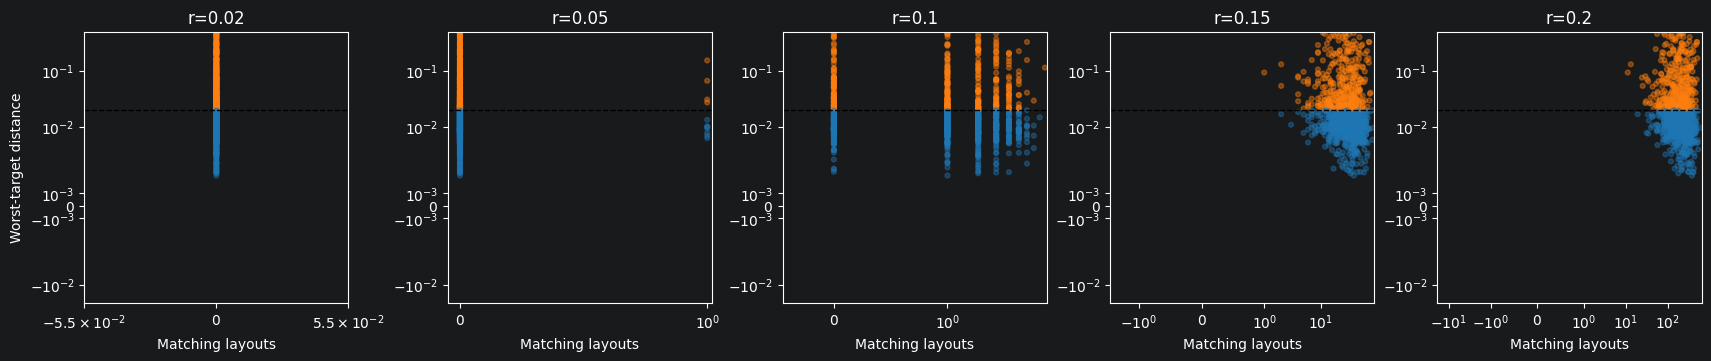

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
colors = {'Success': 'tab:blue', 'Failure': 'tab:orange'}
positions, values, ticklabels, group_colors = [], [], [], []
for j, radius in enumerate(RADII):
    for offset, label, mask in [(-.16, 'Success', success), (.16, 'Failure', ~success)]:
        if mask.any():
            positions.append(j + offset)
            values.append(coverage_counts[mask, j])
            group_colors.append(colors[label])
if values:
    bp = axes[0].boxplot(values, positions=positions, widths=.27, patch_artist=True, showfliers=True)
    for box, color in zip(bp['boxes'], group_colors):
        box.set_facecolor(color)
        box.set_alpha(.65)
axes[0].set_xticks(np.arange(len(RADII)), [f'{r:g}' for r in RADII])
axes[0].set_yscale('symlog', linthresh=1)
axes[0].set(xlabel='Layout radius r', ylabel='Matching training layouts (symlog)',
            title='Coverage: success versus failure')
axes[0].legend(handles=[plt.Line2D([], [], color=c, lw=6, label=g) for g, c in colors.items()])

display_j = int(np.flatnonzero(np.isclose(RADII, DISPLAY_RADIUS))[0])
display_counts = coverage_counts[:, display_j]
edges = [-.5, .5, 4.5, 19.5, 99.5, 499.5, np.inf]
labels = ['0', '1–4', '5–19', '20–99', '100–499', '500+']
binned = pd.cut(display_counts, bins=edges, labels=labels)
bin_rows = []
for label in labels:
    mask = np.asarray(binned == label)
    if mask.any():
        bin_rows.append({'count_bin': label, 'n_layouts': int(mask.sum()),
                         'n_success': int(success[mask].sum()), 'success_rate': success[mask].mean()})
bin_summary = pd.DataFrame(bin_rows)
bin_summary.to_csv(OUTPUT_DIR / 'success_by_coverage_bin.csv', index=False)
axes[1].bar(np.arange(len(bin_summary)), bin_summary['success_rate'], color='tab:blue')
axes[1].set_xticks(np.arange(len(bin_summary)), bin_summary['count_bin'])
for i, row in bin_summary.iterrows():
    axes[1].text(i, row.success_rate + .025, f'n={row.n_layouts}', ha='center', fontsize=9)
axes[1].set(xlabel=f'Matching training layouts at r={DISPLAY_RADIUS:g}', ylabel='Success fraction',
            ylim=(0, 1.15), title=f'Complete visits (tolerance {VISIT_TOLERANCE:g})')
for ax in axes:
    ax.grid(axis='y', alpha=.2)
fig.savefig(OUTPUT_DIR / 'coverage_overview.png', dpi=180)
plt.show()
display(bin_summary)

fig, axes = plt.subplots(1, len(RADII), figsize=(17, 3.5), constrained_layout=True)
for j, ax in enumerate(np.atleast_1d(axes)):
    ax.scatter(coverage_counts[:, j], worst_distance, c=np.where(success, 'tab:blue', 'tab:orange'),
               alpha=.4, s=12)
    ax.axhline(VISIT_TOLERANCE, color='black', ls='--', lw=1)
    ax.set_xscale('symlog', linthresh=1)
    ax.set_yscale('symlog', linthresh=.005)
    ax.set(title=f'r={RADII[j]:g}', xlabel='Matching layouts')
axes[0].set_ylabel('Worst-target distance')
fig.savefig(OUTPUT_DIR / 'coverage_vs_target_error.png', dpi=180)
plt.show()


## 7. Inspect cases and their nearest training layouts
每组按覆盖数量排序，确定性选择低、中、高覆盖案例；不是只选支持假设的案例。可在下方手动填写验证索引。大虚线圆为布局半径，小点线圆为访问容差。


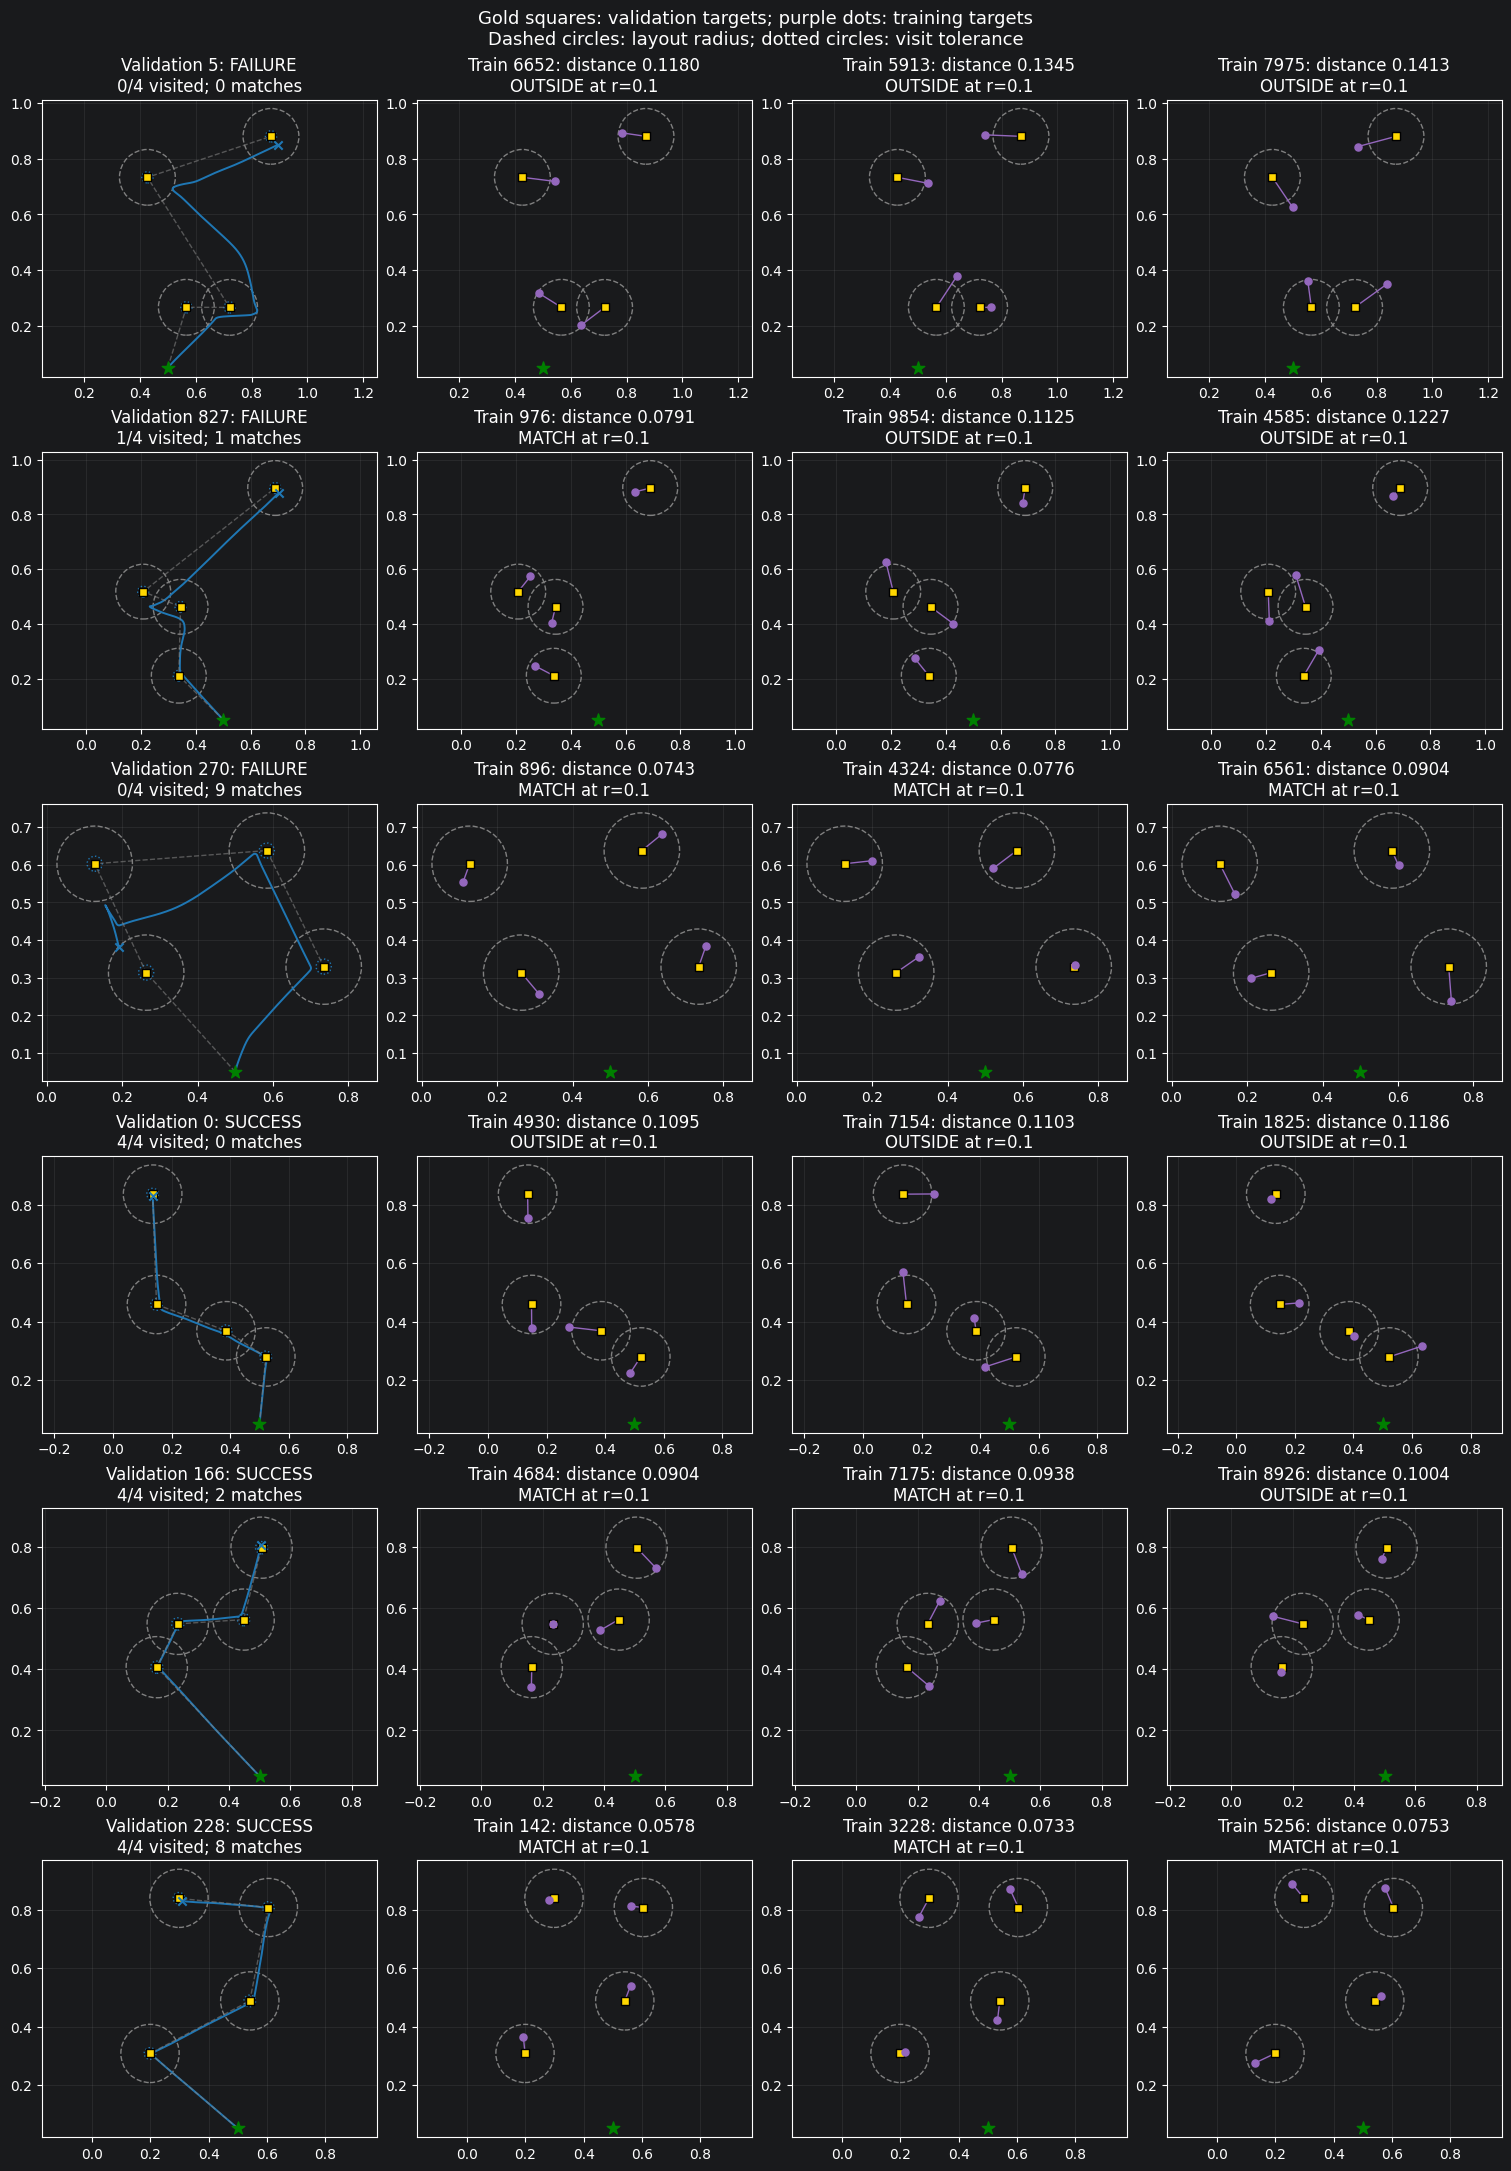

In [40]:
MANUAL_VALIDATION_INDICES = None  # Example: [12, 35]; indices from per_validation_layout.csv
if MANUAL_VALIDATION_INDICES is None:
    case_indices = []
    for mask in [~success, success]:
        indices = np.flatnonzero(mask)
        if len(indices):
            order = indices[np.argsort(display_counts[indices], kind='stable')]
            case_indices.extend(order[np.unique([0, len(order)//2, len(order)-1])].tolist())
else:
    case_indices = list(dict.fromkeys(int(i) for i in MANUAL_VALIDATION_INDICES))
if not case_indices or any(i < 0 or i >= N_VALIDATION for i in case_indices):
    raise ValueError('Provide at least one valid validation index.')

fig, axes = plt.subplots(len(case_indices), 4, figsize=(15, 3.6*len(case_indices)),
                         squeeze=False, constrained_layout=True)
case_rows = []
for row, idx in enumerate(case_indices):
    query = VALIDATION_TARGETS[idx]
    d = matching_distances(query, TRAIN_TARGETS, TRAIN_BLOCK_SIZE)
    nearest = np.argsort(d, kind='stable')[:3]
    case_rows.append({'validation_index': idx, 'success': bool(success[idx]),
                      'radius': DISPLAY_RADIUS, 'matching_count': int(display_counts[idx])})
    for col in range(4):
        ax = axes[row, col]
        for target in query:
            ax.add_patch(Circle(target, DISPLAY_RADIUS, fill=False, color='gray', ls='--', lw=1))
        ax.scatter(query[:, 0], query[:, 1], marker='s', color='gold', edgecolor='black', s=40, zorder=4)
        ax.scatter(*fixed_start, marker='*', color='green', s=90, zorder=5)
        if col == 0:
            path = all_paths[idx]
            ax.plot(path[:, 0], path[:, 1], color='tab:blue', lw=1.4)
            ax.scatter(*path[-1], marker='x', color='tab:blue', zorder=5)
            for target in query:
                ax.add_patch(Circle(target, VISIT_TOLERANCE, fill=False, color='tab:blue', ls=':', lw=1))
            if 'routes' in validation_split:
                route = validation_split['routes'][idx]
                ax.plot(route[:, 0], route[:, 1], color='gray', ls='--', lw=1, alpha=.6)
            ax.set_title(f'Validation {idx}: {"SUCCESS" if success[idx] else "FAILURE"}\n'
                         f'{visit_counts[idx]}/4 visited; {display_counts[idx]} matches')
        elif col <= len(nearest):
            train_idx = nearest[col-1]
            targets = TRAIN_TARGETS[train_idx]
            pair_d = np.linalg.norm(query[:, None] - targets[None], axis=-1)
            costs = pair_d[np.arange(4)[None, :], PERMUTATIONS].max(axis=1)
            permutation = PERMUTATIONS[np.argmin(costs)]
            matched = targets[permutation]
            ax.scatter(targets[:, 0], targets[:, 1], marker='o', color='tab:purple', s=26, zorder=5)
            for a, b in zip(query, matched):
                ax.plot([a[0], b[0]], [a[1], b[1]], color='tab:purple', lw=1)
            ax.set_title(f'Train {train_idx}: distance {d[train_idx]:.4f}\n'
                         f'{"MATCH" if d[train_idx] <= DISPLAY_RADIUS else "OUTSIDE"} at r={DISPLAY_RADIUS:g}')
        else:
            ax.set_visible(False)
        ax.set_aspect('equal', adjustable='datalim')
        ax.grid(alpha=.15)
fig.suptitle('Gold squares: validation targets; purple dots: training targets\n'
             'Dashed circles: layout radius; dotted circles: visit tolerance', fontsize=13)
fig.savefig(OUTPUT_DIR / 'validation_cases_and_nearest_training.png', dpi=160)
plt.show()
pd.DataFrame(case_rows).to_csv(OUTPUT_DIR / 'illustrated_cases.csv', index=False)


## 8. Interpret and share the results

先看所有半径下的 `coverage_group_summary.csv`：失败组是否整体更稀疏？
再看覆盖分组图：是否覆盖越多成功率越高？用误差散点图辅助判断，避免只依赖二值阈值。

- 很多零计数：该半径区分力有限，不能直接得出“覆盖无影响”。
- 失败组计数更少：支持覆盖与表现相关；几何难度、近似等长的竞争顺序等仍可能影响结果。
- 两组接近或方向相反：当前布局距离与半径下，没有支持所提出的方向性假设。
- 五个半径共享同一批布局，不是五次独立重复。下一阶段才需要考虑其他训练种子或补充数据实验。
- 原先 71% 来自 100 个验证布局；本次全部验证布局的成功率不必等于 71%。

将 `coverage_group_summary.csv`、`coverage_overview.png` 和案例图发回来即可一起解读。
逐案例 CSV、轨迹批次、计数缓存和 manifest 保留在输出目录中，可继续复用。


In [17]:
print('Analysis finished. Files saved in:', OUTPUT_DIR)
for name in ['per_validation_layout.csv', 'coverage_group_summary.csv',
             'descriptive_associations.csv', 'success_by_coverage_bin.csv',
             'coverage_overview.png', 'coverage_vs_target_error.png',
             'validation_cases_and_nearest_training.png', 'illustrated_cases.csv', 'manifest.json']:
    print(' -', name)


Analysis finished. Files saved in: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/analysis/coverage_budget_10000_seed_4_visit_005
 - per_validation_layout.csv
 - coverage_group_summary.csv
 - descriptive_associations.csv
 - success_by_coverage_bin.csv
 - coverage_overview.png
 - coverage_vs_target_error.png
 - validation_cases_and_nearest_training.png
 - illustrated_cases.csv
 - manifest.json


In [42]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 沿用刚才 0.05 容差下的成功／失败分类
assert np.isclose(VISIT_TOLERANCE, 0.02), (
    "请先运行之前将访问容差改为 0.05 的单元格。"
)

starts = np.asarray(validation_split["starts"], dtype=np.float64)
targets = np.asarray(validation_split["targets"], dtype=np.float64)
success_mask = np.asarray(success, dtype=bool)

assert len(targets) == len(success_mask)
np.testing.assert_array_equal(
    success_mask,
    (distances <= VISIT_TOLERANCE).all(axis=1),
)

# 24 种目标访问顺序；内部使用编号 0、1、2、3
route_permutations = np.array(
    list(itertools.permutations(range(4))),
    dtype=int,
)

# 每行一个验证布局，每列一种访问顺序
route_lengths = np.empty((len(targets), 24), dtype=np.float64)

for j, permutation in enumerate(route_permutations):
    route = np.concatenate(
        [starts[:, None, :], targets[:, permutation, :]],
        axis=1,
    )
    route_lengths[:, j] = np.linalg.norm(
        np.diff(route, axis=1),
        axis=2,
    ).sum(axis=1)

# 按路线长度排序；相同长度的不同顺序也保留
ranked_orders = np.argsort(route_lengths, axis=1, kind="stable")
rows = np.arange(len(targets))

best_order_index = ranked_orders[:, 0]
second_order_index = ranked_orders[:, 1]

best_length = route_lengths[rows, best_order_index]
second_length = route_lengths[rows, second_order_index]

assert np.all(best_length > 0)

relative_gap = (second_length - best_length) / best_length
gap_percent = 100 * relative_gap

def order_text(order_index):
    # 输出时改成比较直观的编号 1、2、3、4
    return "→".join(
        str(int(x) + 1)
        for x in route_permutations[order_index]
    )

gap_results = pd.DataFrame({
    "validation_index": rows,
    "success": success_mask,
    "visit_tolerance": VISIT_TOLERANCE,
    "best_length": best_length,
    "second_length": second_length,
    "gap_percent": gap_percent,
    "best_order": [order_text(i) for i in best_order_index],
    "second_order": [order_text(i) for i in second_order_index],
})

gap_results.to_csv(
    OUTPUT_DIR / "route_gap_per_validation_layout.csv",
    index=False,
)

print(f"分析了 {len(targets)} 个验证布局，每个布局枚举 24 种顺序。")
print(f"成功 {success_mask.sum()} 个，失败 {(~success_mask).sum()} 个。")
print("gap_percent 的单位是百分比，例如 0.2 表示差距为 0.2%。")

display(gap_results.head(10).round(4))

分析了 1000 个验证布局，每个布局枚举 24 种顺序。
成功 650 个，失败 350 个。
gap_percent 的单位是百分比，例如 0.2 表示差距为 0.2%。


,validation_index,success,visit_tolerance,best_length,second_length,gap_percent,best_order,second_order
0,0,True,0.02,1.0240,1.2923,26.1920,4→2→1→3,2→4→1→3
1,1,True,0.02,1.3140,1.4994,14.1134,3→1→2→4,1→3→2→4
2,2,True,0.02,1.0802,1.2861,19.0542,3→1→4→2,3→1→2→4
3,3,True,0.02,1.3462,1.5373,14.1959,2→1→4→3,2→1→3→4
4,4,True,0.02,1.4618,1.5182,3.8632,2→4→1→3,3→1→4→2
5,5,False,0.02,1.4007,1.4184,1.2698,4→1→3→2,1→4→3→2
6,6,True,0.02,1.3968,1.6071,15.0506,4→2→1→3,4→2→3→1
7,7,False,0.02,1.3613,1.3673,0.4444,2→1→4→3,2→1→3→4
8,8,True,0.02,1.2966,1.3657,5.3315,4→2→3→1,3→4→2→1
9,9,True,0.02,1.7963,1.9596,9.0891,3→4→2→1,1→2→3→4


成功组与失败组的路线长度差距：


,group,n_layouts,mean_gap_percent,median_gap_percent,q25_gap_percent,q75_gap_percent
0,Success,650,9.3967,8.3098,4.7971,13.0654
1,Failure,350,3.8709,2.3673,0.8308,4.9443


不同差距区间内的成功率：


,gap_bin,n_layouts,n_success,success_rate
0,<1%,118,23,0.1949
1,1–<5%,325,157,0.4831
2,5–<10%,261,209,0.8008
3,≥10%,296,261,0.8818


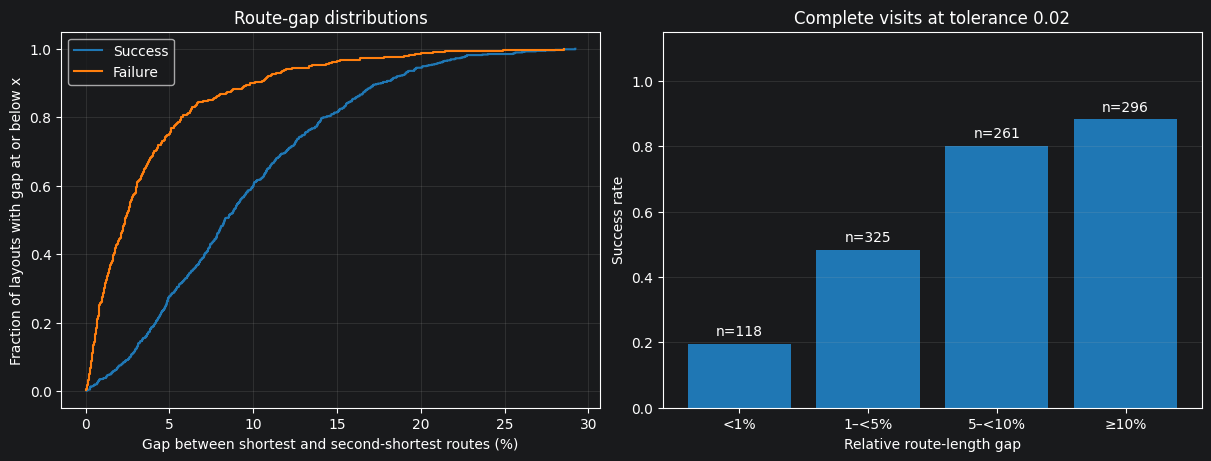

In [43]:
# 成功组与失败组的整体比较
group_rows = []

for label, mask in [
    ("Success", success_mask),
    ("Failure", ~success_mask),
]:
    values = gap_percent[mask]

    group_rows.append({
        "group": label,
        "n_layouts": len(values),
        "mean_gap_percent": values.mean() if len(values) else np.nan,
        "median_gap_percent": np.median(values) if len(values) else np.nan,
        "q25_gap_percent": np.quantile(values, 0.25) if len(values) else np.nan,
        "q75_gap_percent": np.quantile(values, 0.75) if len(values) else np.nan,
    })

gap_group_summary = pd.DataFrame(group_rows)

print("成功组与失败组的路线长度差距：")
display(gap_group_summary.round(4))

# 按相对差距分组，区间左闭右开
bin_edges = [0, 1, 5, 10, np.inf]
bin_labels = ["<1%", "1–<5%", "5–<10%", "≥10%"]

gap_bins = pd.cut(
    gap_percent,
    bins=bin_edges,
    labels=bin_labels,
    right=False,
)

bin_rows = []

for label in bin_labels:
    mask = np.asarray(gap_bins == label)
    n = int(mask.sum())

    bin_rows.append({
        "gap_bin": label,
        "n_layouts": n,
        "n_success": int(success_mask[mask].sum()),
        "success_rate": success_mask[mask].mean() if n else np.nan,
    })

gap_bin_summary = pd.DataFrame(bin_rows)

print("不同差距区间内的成功率：")
display(gap_bin_summary.round(4))

gap_group_summary.to_csv(
    OUTPUT_DIR / "route_gap_group_summary.csv", index=False
)
gap_bin_summary.to_csv(
    OUTPUT_DIR / "route_gap_success_by_bin.csv", index=False
)

# 左图展示完整分布，右图展示分组成功率
fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.5), constrained_layout=True
)

for label, mask, color in [
    ("Success", success_mask, "tab:blue"),
    ("Failure", ~success_mask, "tab:orange"),
]:
    values = np.sort(gap_percent[mask])
    if len(values):
        axes[0].step(
            values,
            np.arange(1, len(values) + 1) / len(values),
            where="post",
            label=label,
            color=color,
        )

axes[0].set(
    xlabel="Gap between shortest and second-shortest routes (%)",
    ylabel="Fraction of layouts with gap at or below x",
    title="Route-gap distributions",
)
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].bar(
    bin_labels,
    gap_bin_summary["success_rate"],
    color="tab:blue",
)

for i, row in gap_bin_summary.iterrows():
    if row["n_layouts"] > 0:
        axes[1].text(
            i,
            row["success_rate"] + 0.025,
            f'n={int(row["n_layouts"])}',
            ha="center",
        )

axes[1].set(
    xlabel="Relative route-length gap",
    ylabel="Success rate",
    ylim=(0, 1.15),
    title=f"Complete visits at tolerance {VISIT_TOLERANCE:g}",
)
axes[1].grid(axis="y", alpha=0.2)

fig.savefig(OUTPUT_DIR / "route_gap_analysis.png", dpi=180)
plt.show()